# TP1 : Classification de voyelles par lois gaussiennes
NOM - PRÉNOM :

Déposer le notebook sur Moodle à la fin de la séance

### Vérification des données


In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
cwd = os.getcwd()
path = "M2_IAFA/TP_M2IAFA/TP_M2_SON/TP1/"

In [3]:
#1- Charger les données d'apprentissage avec le code suivant :
f = open(path+'APP.pkl', 'rb')
dicoAPP = pickle.load(f)
app_aa = dicoAPP["aa"]
app_ii = dicoAPP["ii"]
app_uu = dicoAPP["uu"]
f.close()

# Vérifier le contenu et la taille des matrices
print(f'app_aa : {app_aa.shape} \n  {app_aa[:2]}')
print(f'app_uu : {app_uu.shape} \n {app_uu[:2]}')
print(f'app_ii : {app_ii.shape} \n {app_ii[:2]}')
# Il s'agit de matrices 80x2 résultant d'une ACP sur une paramétrisation cepstrale (cf. cours M1 !).

app_aa : (80, 2) 
  [[ 27.94649426 193.26043937]
 [ 23.14986615 114.84922022]]
app_uu : (80, 2) 
 [[ 43.822864   -16.40654854]
 [ 39.63215773 -16.89754753]]
app_ii : (80, 2) 
 [[-17.53533632 -10.80783246]
 [-17.19142101 -10.31742005]]


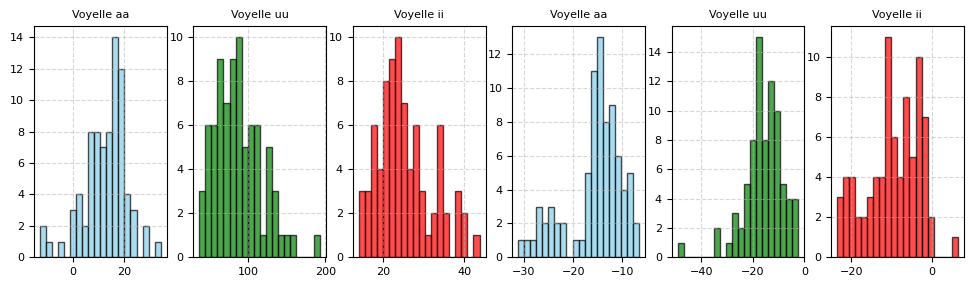

In [4]:
# 2- Afficher sur une seule figure, en utilisant subplot(nb_lignes, nb_colonnes, numero_trace), 
# l'histogramme de chacune des classes : aa, uu et ii.
# Some usefull library
from matplotlib.pyplot import *

# Visualiser l'image originale et l'image filtrée
fig, ax = plt.subplots(1,6, figsize=(12, 3))

ax[0].hist(app_aa[:,0], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax[0].set_title('Voyelle aa', fontsize=8)
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].tick_params(axis='both', which='major', labelsize=8)

ax[1].hist(app_aa[:,1], bins=20, color='green', edgecolor='black', alpha=0.7)
ax[1].set_title('Voyelle uu', fontsize=8)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].tick_params(axis='both', which='major', labelsize=8)

ax[2].hist(app_uu[:,0], bins=20, color='red', edgecolor='black', alpha=0.7)
ax[2].set_title('Voyelle ii', fontsize=8)
ax[2].grid(True, linestyle='--', alpha=0.5)
ax[2].tick_params(axis='both', which='major', labelsize=8)

ax[3].hist(app_uu[:,1], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax[3].set_title('Voyelle aa', fontsize=8)
ax[3].grid(True, linestyle='--', alpha=0.5)
ax[3].tick_params(axis='both', which='major', labelsize=8)

ax[4].hist(app_ii[:,0], bins=20, color='green', edgecolor='black', alpha=0.7)
ax[4].set_title('Voyelle uu', fontsize=8)
ax[4].grid(True, linestyle='--', alpha=0.5)
ax[4].tick_params(axis='both', which='major', labelsize=8)

ax[5].hist(app_ii[:,1], bins=20, color='red', edgecolor='black', alpha=0.7)
ax[5].set_title('Voyelle ii', fontsize=8)
ax[5].grid(True, linestyle='--', alpha=0.5)
ax[5].tick_params(axis='both', which='major', labelsize=8)
  

***Que pouvez-vous conclure ?*** 

::: 

Ces histogrammes issus d'une **paramétrisation cepstrale** montrent la distribution de certaines caractéristiques acoustiques après transformation par ACP et MFCC. 

Le cepstrum est dérivé de la transformée de Fourier inverse du logarithme du spectre du signal et permet de séparer efficacement les caractéristiques de la source et celles du filtre d'un signal. 
  
Cette technique utilisée dans l'analyse de la parole permet de distinguer la forme du tractus vocal (formants) et les vibrations des cordes vocales (pitch). 

Les MFCCs, en utilisant une échelle logarithmique au-dessus de 1000 Hz, permettent d'approcher la perception humaine du son, mais pour séparer explicitement formants et pitch, une analyse plus spécifique du cepstrum ou des spectrogrammes est nécessaire.

$$\large C_r = F^{-1}(log(∣F(x(t))∣))$$

- **Formants**: Les formants sont les fréquences de résonance du tractus vocal. Ils apparaissent généralement à des fréquences plus élevées dans le spectre.

- **Pitch**: Le pitch est lié à la fréquence fondamentale des vibrations des cordes vocales et se situe à des fréquences plus basses.

- **Les barres sur les histogragrammes** représentent la fréquence des occurrences pour des valeurs spécifiques des composants principaux dérivés de la décomposition MFCC. Chaque barre indique la fréquence à laquelle une plage particulière de valeurs se produit dans l'ensemble de données.

**Par exemple** : 
 - Sur l'histogramme "aa" en abscisse  20  est le score d'une composante principale issue de l'analyse des coef. MFCC.  
 - Sur ce même histogramme 14 en ordonnée indique la fréquence d'occurrence de la valeur 20 dans l'ensemble de données.
 - Cette valeur en correspondance MFCC pour le ceptre correposnd à la fréquence foncdamentale du locuteur. 

:::

:::

**Différences entre les Histogrammes** :    

 - Pour chacune des voyelles nous avons deux histogrammes différents.    
 - Lorsque pour une voyelle donnée les distributions sont différentes cela suggère une autre dimension acoustique ou un autre aspect de la voyelle et pourrait s'interpréter comme suit : 

**Forme générale :**
 - La distribution très approximativement normale, ce qui est courant pour la première composante principale d'une ACP.
 - La forme générale, asymétrique, avec une queue plus ou moins longue.

**Centralité :**
 - Le pic de la distribution et sa situation autour du zéro permettant d'apprécier la réparition des échantillons. 
 - Pour une voyelle donnée des valeurs négatives positives ou proches de zéro de la composante principale.

**Dispersion :**
 - Les valeurs s'étendent à - ou + une certaine plage de valeurs, qui soit typique pas des données normalisées.
 - La plus grande concentration de valeurs se trouve entre -x et +y. 
 
 :::

Histogramme 1 (Voyelle "aa"): La concentration autour de 20 pourrait représenter une caractéristique liée au pitch ou à une composante principale capturant cette information.
Histogramme 2 (Voyelle "aa"): La répartition autour de 100 pourrait être liée aux formants, reflétant la forme du tractus vocal.

 :::
 
**Histogramme 2:**      
- **Distribution**: 
 - Les valeurs autour de 100-200 pourraient représenter des scores issus d'une analyse en composantes principales (ACP) appliquée aux coefficients MFCC.   
 - La répartition autour de 100 pourrait être liée aux formants, reflétant la forme du tractus vocal. 
     
- **Objectif**: Cet histogramme pourrait montrer la distribution des scores d'une composante principale spécifique, capturant une variation importante dans les données.

**Histogramme 1**:    
- **Distribution** : 
 - Les valeurs autour de 20 indiquent une autre caractéristique, probablement un coefficient MFCC ou un autre score transformé.
 - La concentration autour de 20 pourrait représenter une caractéristique liée au pitch ou à une composante principale capturant cette information.
     
- **Objectif**: Cet histogramme montre la fréquence d'occurrence d'une autre caractéristique acoustique, différente de celle représentée dans le premier histogramme.

:::

### Utilisation de lois gaussiennes

##### 3) APPRENTISSAGE : 
**Estimer les paramètres (moyenne et matrice de covariance) de chaque classe** .  
**Quelles sont les dimensions des variables crées ; que contiennent-elles ?** 

**Estimation des Paramètres**
- **Moyenne (Mean)** 
  - Calculez la moyenne de chaque classe (voyelle) en utilisant les valeurs des caractéristiques acoustiques.
  - La moyenne est la somme des valeurs divisée par le nombre total de valeurs.
- **Matrice de Covariance**
  - Calculez la matrice de covariance pour chaque classe. 
  - La covariance mesure comment deux variables varient ensemble.
  - Pour un ensemble de données multidimensionnel, la matrice de covariance est calculée comme suit :

- $\sum =\Large \frac{1 }{N-1}*\large  \sum_{i=1}^{N} (x_i - \mu) @ (x_i - \mu)^T$
  - $x_i$ est un vecteur de données,    
  - $\mu$ est le vecteur moyen,    
  - $N$ est le nombre total d'échantillons.   

 - Lorsque l'on a une matrice de données, axis=0 calcule la moyenne pour chaque colonne. 
 - Cela signifie que l'on obtient un vecteur moyen qui représente la moyenne de chaque caractéristique à travers tous les échantillons.
 - Chaque ligne est traitée comme une observation distincte, et chaque colonne est une caractéristique.  

In [5]:
def compute_mean_cov(echantillions):
    class_param=[]
    for type, echantillion in echantillions :
        mean = np.mean(echantillion, axis=0)
        # Center the data
        centered_data = echantillion -  mean
        # Calculate the covariance matrix
        cov_matrix = np.dot(centered_data.T, centered_data) / (echantillion.shape[0] - 1)
        class_param.append((type,mean,cov_matrix))
    return class_param

echantillions=[("aa",app_aa),("uu",app_uu),("ii",app_ii)]
class_param = compute_mean_cov(echantillions)
class_param

[('aa',
  array([12.73410809, 86.9221835 ]),
  array([[ 73.95541499, -74.69081838],
         [-74.69081838, 912.23345829]])),
 ('uu',
  array([ 25.36460256, -15.63309221]),
  array([[ 45.53917015, -27.27292986],
         [-27.27292986,  31.08463331]])),
 ('ii',
  array([-15.84258271,  -9.71847791]),
  array([[ 57.07718836, -30.90012588],
         [-30.90012588,  42.72735791]]))]

#### 4) RECONNAISSANCE : 

 - **Ecrire une fonction "classer" qui renvoie la classe obtenue par maximum de vraisemblance sur les lois gaussiennes estimées (modèle de chaque classe) sur l'observation fournie en entrée**

In [6]:
from scipy.linalg import sqrtm

def classer(tst_aa, class_param):  
    result=[]
    for i, (label, mean, cov_matrix) in enumerate(class_param):
        # Calculate the determinant and inverse of covariance matrix
        det_cov = np.linalg.det(cov_matrix)  
        inv_cov = np.linalg.inv(cov_matrix)
        # Calculate the denominator
        denum = (2 * np.pi) ** (len(mean) / 2) * np.sqrt(det_cov)       
        # Calculate the exponent part
        diff = tst_aa - mean
        part1 = -0.5 * np.dot(diff.T, np.dot(inv_cov, diff))        
        # Calculate numerator
        numer = np.exp(part1)        
        # Append the result
        result.append((label, (numer/denum))) 
    data = [x[1] for x in result] 
    return class_param[np.argmax(data)][0]

out= classer(app_aa[70,:], class_param)
print(f'app_aa --> app_{out}')
out= classer(app_uu[70,:], class_param)
print(f'app_uu --> app_{out}')
out= classer(app_ii[70,:], class_param)
print(f'app_ii --> app_{out}')

app_aa --> app_aa
app_uu --> app_uu
app_ii --> app_ii


In [7]:
#5- Des observations à tester sont présentes dans le fichier Pickle suivant : TST.pkl
# Charger ces données de tests comme pour les données d'apprentissage)
# Vérifier leur dimensions et leur contenu
g = open('TST.pkl', 'rb')
dicoTST = pickle.load(g)
TST_aa = dicoTST["aa"]
TST_ii = dicoTST["ii"]
TST_uu = dicoTST["uu"]
g.close()

# Vérifier le contenu et la taille des matrices
print(f'TST_aa : {TST_aa.shape} \n  {TST_aa[1,:]}')
print(f'TST_uu : {TST_uu.shape} \n {TST_uu[1,:]}')
print(f'TST_ii : {TST_ii.shape} \n {TST_ii[1,:]}')

TST_aa : (20, 2) 
  [15.01573001 41.00905922]
TST_uu : (20, 2) 
 [18.33295967 -9.25915595]
TST_ii : (20, 2) 
 [-9.65790036 -4.12177997]


In [8]:
#6- Définir la fonction tout_tester qui effectue tous les tests de classification 

def tout_tester(echantillons):
    result=[]
    class_param = compute_mean_cov(echantillions)
    for type, echantillon in echantillons : 
        for row in range(echantillon.shape[0]):
            label = classer(echantillon[row,:], class_param)
            result.append((type, echantillon[row,:],label ))
    return result

class_param=[]
echantillions=[("aa",TST_aa),("uu",TST_uu),("ii",TST_ii)]
class_param = tout_tester(echantillions)
class_param[:3]

[('aa', array([11.77415839, 54.17821404]), 'aa'),
 ('aa', array([15.01573001, 41.00905922]), 'aa'),
 ('aa', array([ 3.76834603, 60.42549292]), 'aa')]

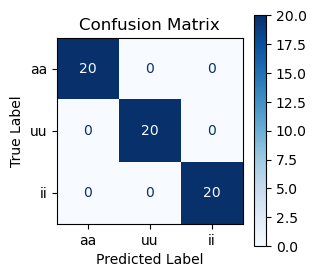

In [9]:
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Example actual and predicted labels
actual = [t[0] for t in class_param]
predicted =  [t[2] for t in class_param]

# Generate the confusion matrix
conf_matrix = metrics.confusion_matrix(actual, predicted, labels=['aa', 'uu', 'ii'])

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['aa', 'uu', 'ii'])
# Customize the plot
fig, ax = plt.subplots(figsize=(3, 3))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### 8- Commenter les résultats obtenus :
- Nous avons un taux de reconnaissance de 1 
- aucun faux positif
- aucun faux négatif 
- 20 vrais positifs pour chacune des classes.


### Visualisation  des résultats

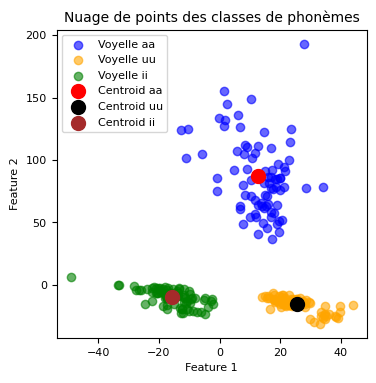

In [10]:
#9- Représenter en 2D et par des couleurs différentes les nuages de points correspondant 
# aux données d'apprentissage
import numpy as np
import matplotlib.pyplot as plt

# Example data for three classes
class_labels = ['aa', 'uu', 'ii']
n_samples = 100

echantillions=[("aa",app_aa),("uu",app_uu),("ii",app_ii)]
#echantillions=[("aa",TST_aa),("uu",TST_uu),("ii",TST_ii)]
class_aa =np.array([ (val1[0],val1[1]) for val1 in echantillions[0][1]])
class_uu =np.array([ (val1[0],val1[1]) for val1 in echantillions[1][1]])
class_ii =np.array([ (val1[0],val1[1]) for val1 in echantillions[2][1]])

# Plot the data
plt.figure(figsize=(4, 4))

# Plotting all classes with different colors
plt.scatter(class_aa[:, 0], class_aa[:, 1], color='blue', label='Voyelle aa', alpha=0.6)
plt.scatter(class_uu[:, 0], class_uu[:, 1], color='orange', label='Voyelle uu', alpha=0.6)
plt.scatter(class_ii[:, 0], class_ii[:, 1], color='green', label='Voyelle ii', alpha=0.6)

# Plot centroids
class_param = compute_mean_cov(echantillions)
plt.scatter(class_param[0][1][0], class_param[0][1][1], color='red', marker='o', s=100, label='Centroid aa')
plt.scatter(class_param[1][1][0], class_param[1][1][1], color='black', marker='o', s=100, label='Centroid uu')
plt.scatter(class_param[2][1][0], class_param[2][1][1], color='brown', marker='o', s=100, label='Centroid ii')

# Customizing the plot
plt.title('Nuage de points des classes de phonèmes', fontsize=10)
plt.xlabel('Feature 1', fontsize=8)
plt.ylabel('Feature 2', fontsize=8)
# Set size of scale numbers
plt.xticks(fontsize=8)  
plt.yticks(fontsize=8)  
plt.legend(fontsize=8)
plt.grid(False)
plt.show()

#10- Afficher les centroïdes des différentes classes

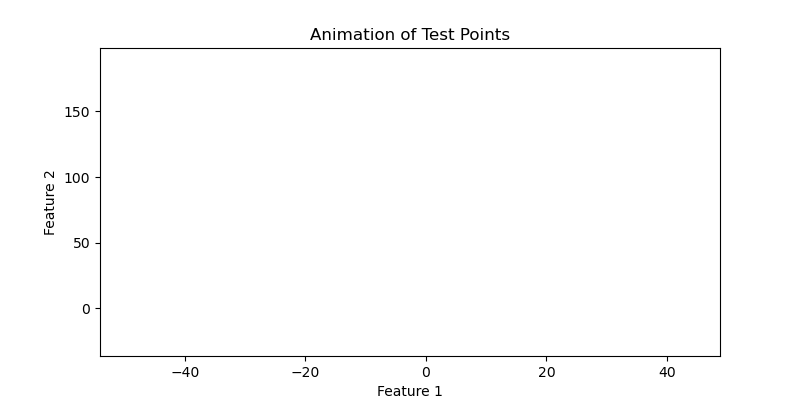

In [11]:

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

#echantillions = [("aa", TST_aa), ("uu", TST_uu), ("ii", TST_ii)]
echantillions = [("aa", app_aa), ("uu", app_uu), ("ii", app_ii)]
n_samples = echantillions[0][1].shape[0]

class_aa = [ (val1[0], val1[1]) for val1 in echantillions[0][1]]
class_uu = [ (val1[0], val1[1]) for val1 in echantillions[1][1]]
class_ii = [ (val1[0], val1[1]) for val1 in echantillions[2][1]]

# Combine all data points and labels
data = np.concatenate([class_aa, class_uu, class_ii])
labels = ['aa'] * n_samples + ['uu'] * n_samples + ['ii'] * n_samples

# Create a scatter plot
fig, ax = plt.subplots(figsize=(8, 4))
fig.subplots_adjust(hspace=0.1)
colors = {'aa': 'blue', 'uu': 'red', 'ii': 'green'}
scatter = ax.scatter([], [], c=[],s=50)

# Set plot limits and labels
ax.set_xlim(np.min(data[:, 0]) - 5, np.max(data[:, 0]) + 5)
ax.set_ylim(np.min(data[:, 1]) - 5, np.max(data[:, 1]) + 5)
ax.set_title('Animation of Test Points')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

# Update function for animation
def update(frame):
    current_data = data[:frame+1]
    current_labels = labels[:frame+1]
    scatter.set_offsets(current_data)
    scatter.set_color([colors[label] for label in current_labels])
    return scatter,

# Create animation
anim = FuncAnimation(fig, update, frames=len(data), interval=100, blit=False)
plt.show()